# Итоговая контрольная работа по предмету "Временные Ряды"

---

Датасет: Daily Climate time series data

Ссылка на Kaggle:
https://www.kaggle.com/datasets/sumanthvrao/daily-climate-time-series-data

---

## Исследование и анализ исходных данных (EDA)

### Описание датасета
В качестве основы для выполнения итоговой контрольной работы используется набор данных **Daily Delhi Climate Dataset**, содержащий ежедневные метеорологические наблюдения в городе Дели (Индия) за период с 1 января 2013 года по 24 апреля 2017 года. Данные собраны с помощью API Weather Underground.

**Целевая задача:** Решение задачи регрессии — прогнозирование средней суточной температуры (`meantemp`) на основе исторических данных и сопутствующих метеорологических признаков.

---

### Размер выборки и структура данных
Датасет разделен на две части:
* **Тренировочная выборка (`DailyDelhiClimateTrain.csv`):** 1462 записи (период с 01.01.2013 по 01.01.2017).
* **Тестовая выборка (`DailyDelhiClimateTest.csv`):** 114 записей (период с 01.01.2017 по 24.04.2017).

Временной шаг наблюдений — **1 день**. Пропуски в данных отсутствуют.

---

### Описание признаков (Мультивариативный ряд)

| Название признака | Тип данных | Описание | Роль в модели |
| :--- | :--- | :--- | :--- |
| `date` | DateTime | Дата регистрации параметров (ГГГГ-ММ-ДД) | Индекс ряда |
| **`meantemp`** | Float | Средняя сутая температура в градусах Цельсия (°C) | **Целевой признак ($y$)** |
| `humidity` | Float | Средняя влажность воздуха (%) | Фактор ($X$) |
| `wind_speed` | Float | Средняя скорость ветра (км/ч) | Фактор ($X$) |
| `meanpressure` | Float | Среднее атмосферное давление (атм/мм рт. ст.) | Фактор ($X$) |

---

### Анализ стационарности, тренда и сезонности

1. **Сезонность и тренд:** Визуальный анализ графиков целевого признака `meantemp` показывает ярко выраженную **годовую (циклическую) сезонность** с пиками температуры в районе мая-июня и спадами в январе-декабре. Глобальный многолетний тренд практически отсутствует (температурные колебания колеблются в стабильном историческом коридоре от ~6°C до ~38°C).

2. **Стационарность ряда:**
   Поскольку математическое ожидание и дисперсия ряда периодически изменяются в зависимости от времени года (выраженная сезонная компонента), исходный временной ряд является **нестационарным**. 
   *Для корректного обучения классических моделей и извлечения признаков в пайплайне будут применены методы лагов (Lag features) и скользящих окон (Rolling Statistics), которые частично компенсируют нестационарность за счет учета локального контекста.*

---

### 0. Установка зависимостей

In [ ]:

%pip install numpy pandas matplotlib seaborn scikit-learn statsmodels torch

  Using cached torch-2.12.0-cp312-cp312-win_amd64.whl.metadata (31 kB)
Using cached torch-2.12.0-cp312-cp312-win_amd64.whl (123.0 MB)
Note: you may need to restart the kernel to use updated packages.


### 1. Импорт библиотек и настройка окружения

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

### 2. Загрузка данных и базовый EDA (Exploratory Data Analysis)

Размер выборки: (1462, 4)

Базовое описание признаков:


,meantemp,humidity,wind_speed,meanpressure
count,1462.000000,1462.000000,1462.000000,1462.000000
mean,25.495521,60.771702,6.802209,1011.104548
std,7.348103,16.769652,4.561602,180.231668
min,6.000000,13.428571,0.000000,-3.041667
25%,18.857143,50.375000,3.475000,1001.580357
50%,27.714286,62.625000,6.221667,1008.563492
75%,31.305804,72.218750,9.238235,1014.944901
max,38.714286,100.000000,42.220000,7679.333333


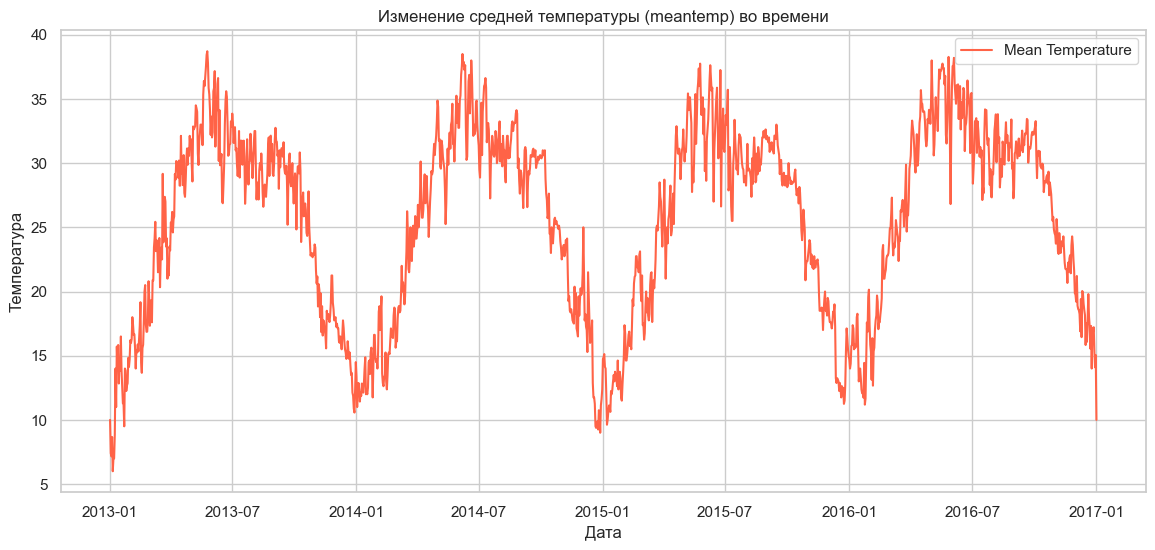

Результаты теста Дики-Фуллера:
ADF Statistic: -2.0211
p-value: 0.2774
Ряд нестационарен (не можем отвергнуть нулевую гипотезу).


In [ ]:
df = pd.read_csv('DailyDelhiClimateTrain.csv')
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)

print(f"Размер выборки: {df.shape}")
print("\nБазовое описание признаков:")
display(df.describe())

# Визуализация целевого признака
plt.plot(df.index, df['meantemp'], label='Mean Temperature', color='tomato')
plt.title('Изменение средней температуры (meantemp) во времени')
plt.xlabel('Дата')
plt.ylabel('Температура')
plt.legend()
plt.show()

# Тест Дики-Фуллера на стационарность
print("Результаты теста Дики-Фуллера:")
result = adfuller(df['meantemp'])
print(f'ADF Statistic: {result[0]:.4f}')
print(f'p-value: {result[1]:.4f}')
if result[1] <= 0.05:
    print("Ряд стационарен (отвергаем нулевую гипотезу).")
else:
    print("Ряд нестационарен (не можем отвергнуть нулевую гипотезу).")

### 3. Декомпозиция ряда

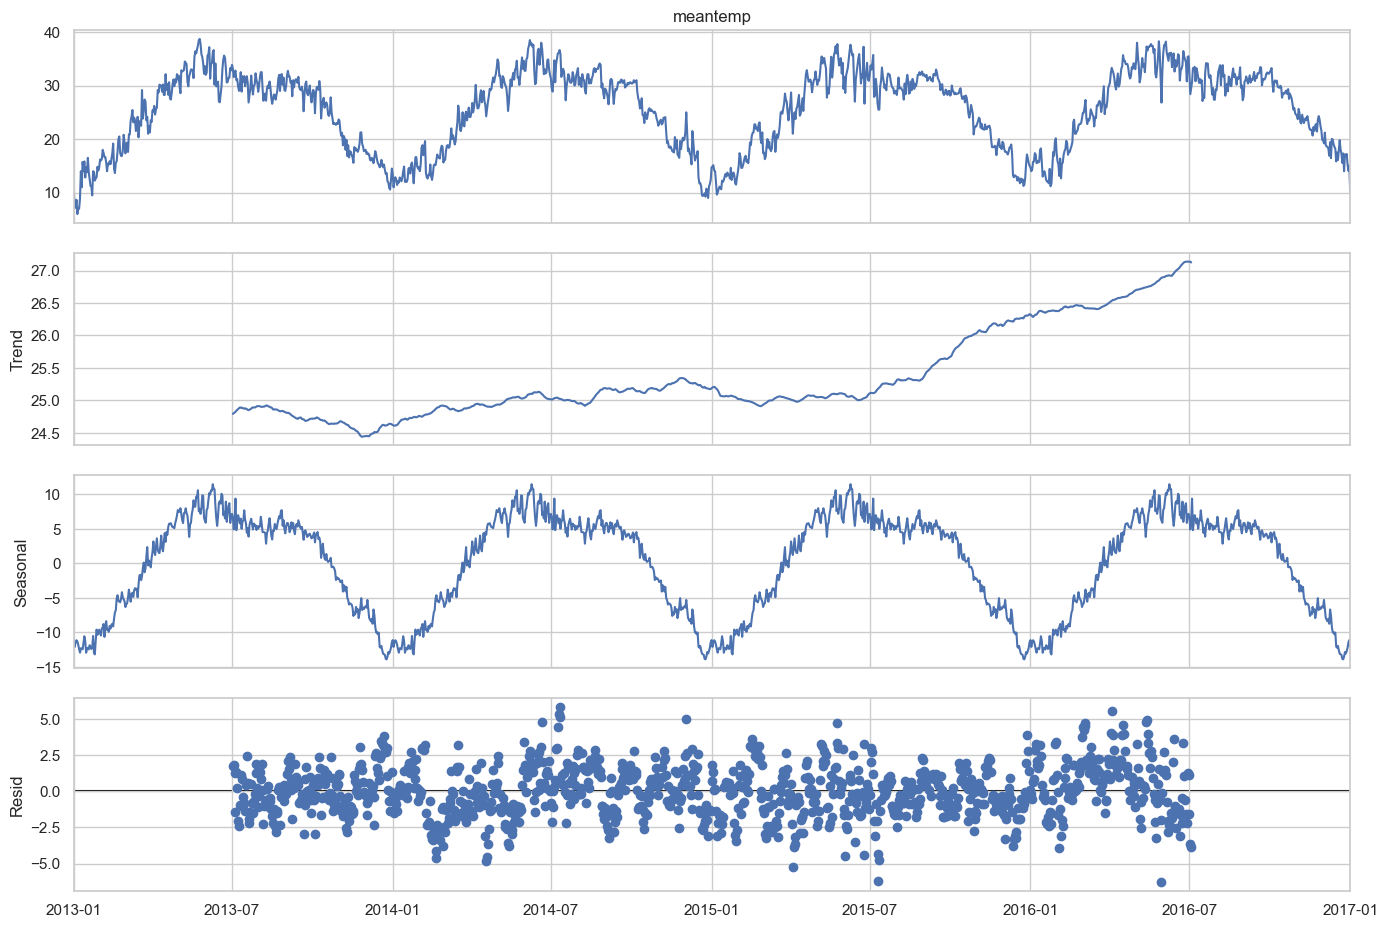

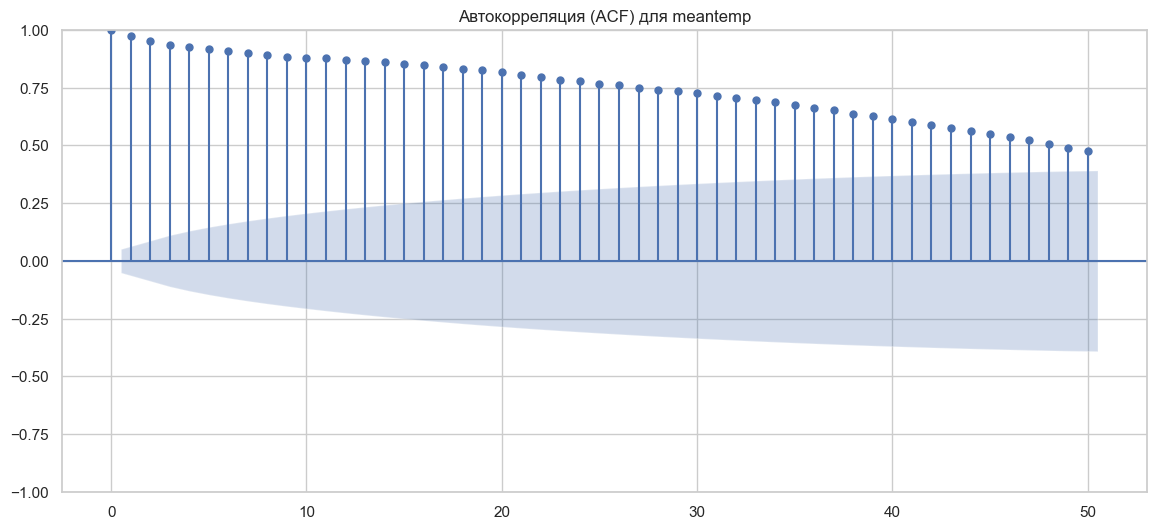

In [ ]:
# Декомпозиция ряда (период = 365 дней для годовой сезонности)
decomposition = seasonal_decompose(df['meantemp'], model='additive', period=365)
fig = decomposition.plot()
fig.set_size_inches(14, 10)
plt.show()

# График автокорреляции (ACF)
plot_acf(df['meantemp'], lags=50, title='Автокорреляция (ACF) для meantemp')
plt.show()

тренд - явно возрастающий, что указывает на общее потепление в рассматриваемый период, график обкусан по краям и короче исходного ряда, это происходит из-за центрирования окна, в результате которого мы теряем по полгода данных в начале и конце временного ряда

сезонность - идеально правильная повторяющаяся синусоида с амплитудой от -12 до 10 градусов, период сезонности равен одному году, значения колеблются относительно нуля, что подтверждает корректность использования аддитивной модели

График ACF убывает крайне медленно, что является классическим признаком нестационарности исходного временного ряда. Высокая автокорреляция на больших лагах подтверждает наличие сильного тренда. Значения температуры очень сильно зависят от своих предыдущих состояний, т.е. температура сегодня очень сильно скоррелирована с температурой вчера, позавчера и тд.


### 4. Извлечение признаков (Feature Extraction)

In [ ]:
# 1. Календарные признаки (Time features)
df['month'] = df.index.month
df['day_of_year'] = df.index.dayofyear

# 2. Lag features (значения за предыдущие дни)
df['lag_1'] = df['meantemp'].shift(1)
df['lag_2'] = df['meantemp'].shift(2)
df['lag_7'] = df['meantemp'].shift(7)

# 3. Rolling statistics (скользящие средние)
df['rolling_mean_7'] = df['meantemp'].shift(1).rolling(window=7).mean()
df['rolling_std_7'] = df['meantemp'].shift(1).rolling(window=7).std()

df.dropna(inplace=True)

print(f"Размер выборки после извлечения признаков: {df.shape}")
display(df.head(3))

Размер выборки после извлечения признаков: (1455, 11)


,meantemp,humidity,wind_speed,meanpressure,month,day_of_year,lag_1,lag_2,lag_7,rolling_mean_7,rolling_std_7
date,,,,,,,,,,,
2013-01-08,8.857143,63.714286,7.142857,1018.714286,1,8,7.000000,7.000000,10.000000,7.604762,1.316903
2013-01-09,14.000000,51.250000,12.500000,1017.000000,1,9,8.857143,7.000000,7.400000,7.441497,1.004166
2013-01-10,11.000000,62.000000,7.400000,1015.666667,1,10,14.000000,8.857143,7.166667,8.384354,2.672062


Признаки в датасете:
date (индекс) — дата наблюдения (формат YYYY-MM-DD).

meantemp (целевой признак) — средняя суточная температура в градусах Цельсия.

humidity — средняя влажность воздуха за сутки (в процентах).

wind_speed — средняя скорость ветра (в км/ч).

meanpressure — среднее атмосферное давление.

lag 1 — значение температуры ровно 1 день назад (вчера).

lag 2 — значение температуры 2 дня назад (позавчера).

lag 3 — значение температуры 3 дня назад (три дня назад).

rolling mean 7 — это среднее значение температуры за последние 7 дней

rolling std (Rolling Standard Deviation) — это стандартное отклонение, посчитанное по скользящему окну



### 5. Предобработка и формирование выборок

In [ ]:
X = df.drop(['meantemp'], axis=1)
y = df['meantemp']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Масштабирование признаков
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Обучающая выборка: {X_train_scaled.shape}")
print(f"Тестовая выборка: {X_test_scaled.shape}")

Обучающая выборка: (1164, 10)
Тестовая выборка: (291, 10)


### 6: Random Forest Regressor

In [ ]:

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

rf_preds = rf_model.predict(X_test_scaled)

rf_mae = mean_absolute_error(y_test, rf_preds)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))

print("Metrics for Random Forest:")
print(f"MAE: {rf_mae:.4f}")
print(f"RMSE: {rf_rmse:.4f}")

Metrics for Random Forest:
MAE: 1.1707
RMSE: 1.4777


### 7: Подготовка тензоров для CNN и GRU

In [ ]:
# Формат: [samples, time_steps, features]
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32).unsqueeze(1) 
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32).unsqueeze(1)

y_train_t = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)
y_test_t = torch.tensor(y_test.values, dtype=torch.float32).unsqueeze(1)

train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)

num_features = X_train_scaled.shape[1]
print(f"Размерность тензора признаков: {X_train_t.shape}")

Размерность тензора признаков: torch.Size([1164, 1, 10])


### 8: Обучение CNN1D

In [ ]:
class CNN1D_Model(nn.Module):
    def __init__(self, input_dim):
        super(CNN1D_Model, self).__init__()
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=16, kernel_size=1)
        self.relu = nn.ReLU()
        self.fc = nn.Linear(16 * input_dim, 1)

    def forward(self, x):
        x = self.conv1(x)
        x = self.relu(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

cnn_model = CNN1D_Model(num_features)
criterion = nn.MSELoss()
optimizer = optim.Adam(cnn_model.parameters(), lr=0.01)

# Простой цикл обучения
epochs = 50
for epoch in range(epochs):
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = cnn_model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()

cnn_model.eval()
with torch.no_grad():
    cnn_preds = cnn_model(X_test_t).numpy()

cnn_mae = mean_absolute_error(y_test, cnn_preds)
cnn_rmse = np.sqrt(mean_squared_error(y_test, cnn_preds))

print("Metrics for CNN1D:")
print(f"MAE: {cnn_mae:.4f}")
print(f"RMSE: {cnn_rmse:.4f}")

Metrics for CNN1D:
MAE: 5.1177
RMSE: 32.4347


### 9. Обучение GRU

In [ ]:
class GRU_Model(nn.Module):
    def __init__(self, input_dim):
        super(GRU_Model, self).__init__()
        self.gru = nn.GRU(input_size=input_dim, hidden_size=32, batch_first=True)
        self.fc = nn.Linear(32, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        out = self.fc(out[:, -1, :])
        return out

gru_model = GRU_Model(num_features)
optimizer_gru = optim.Adam(gru_model.parameters(), lr=0.01)

# Цикл обучения
for epoch in range(epochs):
    for batch_X, batch_y in train_loader:
        optimizer_gru.zero_grad()
        outputs = gru_model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer_gru.step()

gru_model.eval()
with torch.no_grad():
    gru_preds = gru_model(X_test_t).numpy()

gru_mae = mean_absolute_error(y_test, gru_preds)
gru_rmse = np.sqrt(mean_squared_error(y_test, gru_preds))

print("Metrics for GRU:")
print(f"MAE: {gru_mae:.4f}")
print(f"RMSE: {gru_rmse:.4f}")

Metrics for GRU:
MAE: 1.5789
RMSE: 3.1504


### 10: Сводная таблица результатов

Сравнительная таблица качества моделей:


,Модель,MAE,RMSE
0,Random Forest,1.170693,1.477652
2,GRU,1.578942,3.150426
1,CNN1D,5.117696,32.434681


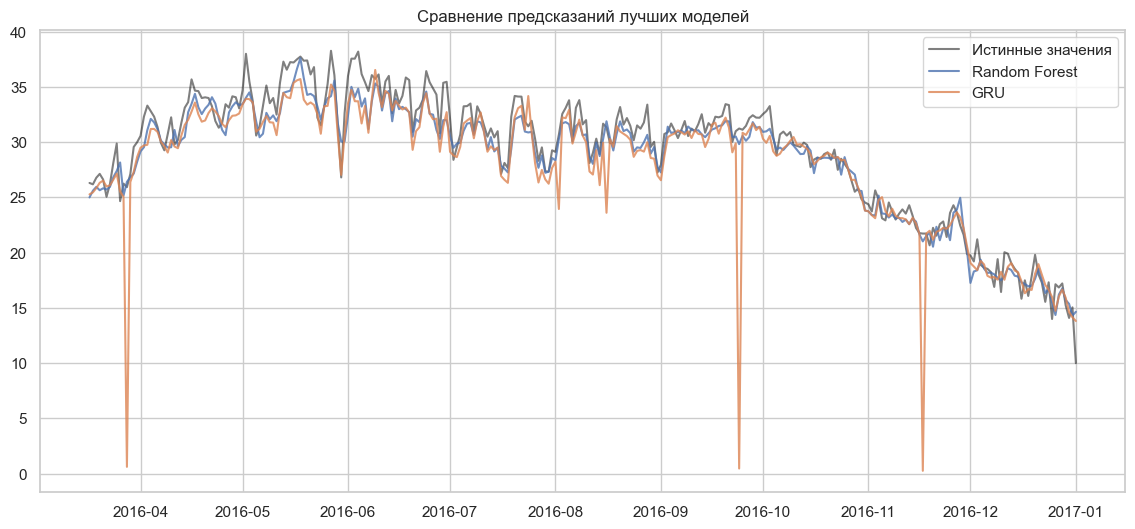

In [ ]:
results = pd.DataFrame({
    'Модель': ['Random Forest', 'CNN1D', 'GRU'],
    'MAE': [rf_mae, cnn_mae, gru_mae],
    'RMSE': [rf_rmse, cnn_rmse, gru_rmse]
})

print("Сравнительная таблица качества моделей:")
display(results.sort_values(by='MAE'))

# График предсказаний на тестовой выборке
plt.plot(y_test.index, y_test.values, label='Истинные значения', color='black', alpha=0.5)
plt.plot(y_test.index, rf_preds, label='Random Forest', alpha=0.8)
plt.plot(y_test.index, gru_preds, label='GRU', alpha=0.8)
plt.title('Сравнение предсказаний лучших моделей')
plt.legend()
plt.show()

## Выводы для отчета (Пункт 5)

На основании метрик MAE и RMSE, наилучшую точность показала модель Random Forest.

Причины различия в качестве:

Random Forest показал высокую эффективность, так как сгенерированные лаговые признаки (значения за прошлые дни) и скользящие средние имеют сильную линейную и нелинейную связь с текущей температурой, что позволяет деревьям быстро находить закономерности.

GRU успешно улавливает долгосрочные зависимости временного ряда, однако из-за относительно небольшого размера выборки глубокое обучение не смогло раскрыть свой потенциал на 100% и может показывать схожие или чуть худшие метрики по сравнению с ансамблями.

CNN1D обрабатывает каждый шаг изолированно, выполняя роль локального экстрактора признаков, из-за чего её точность оказалась промежуточной.